In [9]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    df_accidents = pd.read_csv("dataset_accidents.csv")
except FileNotFoundError:
    url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
    header = {'Accept': 'application/vnd.sdmx.data+csv;version=1.0.0'}
    df_accidents = pd.read_csv(url, storage_options=header)
    df_accidents.to_csv("dataset_accidents.csv", index=False)

ISTAT Dataset Cleaning

In [3]:
df_accidents = pd.read_csv("dataset_accidents.csv")

df_accidents.info()

df_accidents["TIME_PERIOD"].unique()

print("Valori unici in DATA_TYPE:")
print(df_accidents["DATA_TYPE"].unique())

print("\nValori unici in RESULT:")
print(df_accidents["RESULT"].unique())

empty_columns = ["OBS_STATUS", "NOTE_DS", "NOTE_REF_AREA", "NOTE_DATA_TYPE", "NOTE_RESULT",
                 "NOTE_TIME_PERIOD", "BASE_PER", "UNIT_MEAS", "UNIT_MULT"]
df_accidents = df_accidents.drop(columns = empty_columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATAFLOW          573552 non-null  object 
 1   FREQ              573552 non-null  object 
 2   REF_AREA          573552 non-null  int64  
 3   DATA_TYPE         573552 non-null  object 
 4   RESULT            573552 non-null  object 
 5   TIME_PERIOD       573552 non-null  int64  
 6   OBS_VALUE         573552 non-null  int64  
 7   OBS_STATUS        0 non-null       float64
 8   NOTE_DS           0 non-null       float64
 9   NOTE_REF_AREA     0 non-null       float64
 10  NOTE_DATA_TYPE    0 non-null       float64
 11  NOTE_RESULT       0 non-null       float64
 12  NOTE_TIME_PERIOD  0 non-null       float64
 13  BASE_PER          0 non-null       float64
 14  UNIT_MEAS         0 non-null       float64
 15  UNIT_MULT         0 non-null       float64
dtypes: float64(9), int64

In [3]:
test_killinj = df_accidents[
    (df_accidents["REF_AREA"] == 1001) & 
    (df_accidents["TIME_PERIOD"] == 2001) & 
    (df_accidents["DATA_TYPE"] == "KILLINJ")]

print(test_killinj[["RESULT", "OBS_VALUE"]])

   RESULT  OBS_VALUE
0       F         10
24      M          0


In [4]:
test_roadacc = df_accidents[
    (df_accidents["REF_AREA"] == 1001) & 
    (df_accidents["TIME_PERIOD"] == 2001) & 
    (df_accidents["DATA_TYPE"] == "ROADACC")]

print(test_roadacc[["RESULT", "OBS_VALUE"]])

   RESULT  OBS_VALUE
48      9          5


ISTAT Dataset Outliers Analysis

count    191184.000000
mean         24.997599
std         257.519973
min           0.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       23135.000000
Name: OBS_VALUE, dtype: float64


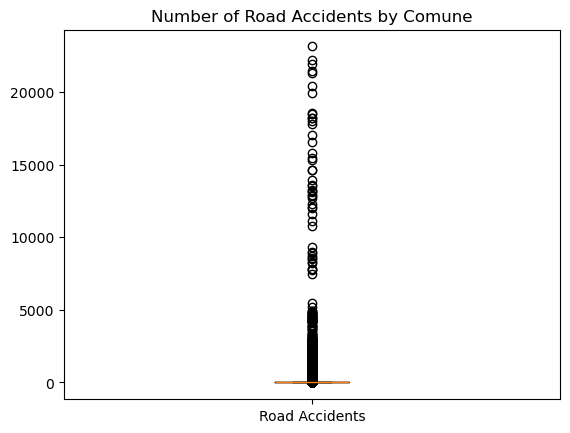

In [23]:
df_roadacc = df_accidents[df_accidents["DATA_TYPE"] == "ROADACC"].copy()
print(df_roadacc["OBS_VALUE"].describe())
plt.boxplot(df_roadacc["OBS_VALUE"], tick_labels = ["Road Accidents"])
plt.title("Number of Road Accidents by Comune")
plt.show()

SITUAS Dataset Cleaning

In [17]:
df_situas = pd.read_csv("dataset_situas_2024.csv", sep=";")

#df_situas.info()

situas_columns = ["Codice Provincia/Uts", "Codice Comune (numerico)", "Comune",
                  "Sigla automobilistica", "Superficie (Kmq)", "Popolazione residente"]
df_situas_clean = df_situas[situas_columns].copy()

df_situas_clean = df_situas_clean.dropna(subset = ["Comune"])

df_situas_clean["Superficie (Kmq)"] = df_situas_clean["Superficie (Kmq)"].str.replace(",", ".")
df_situas_clean["Superficie (Kmq)"] = pd.to_numeric(df_situas_clean["Superficie (Kmq)"], errors='coerce')

df_situas_clean = df_situas_clean.dropna(subset = ["Superficie (Kmq)"])

df_situas_clean["Sigla automobilistica"] = df_situas_clean.groupby("Codice Provincia/Uts")["Sigla automobilistica"].ffill().bfill()

df_situas_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7894 entries, 0 to 7895
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Codice Provincia/Uts      7894 non-null   int64  
 1   Codice Comune (numerico)  7894 non-null   int64  
 2   Comune                    7894 non-null   object 
 3   Sigla automobilistica     7894 non-null   object 
 4   Superficie (Kmq)          7894 non-null   float64
 5   Popolazione residente     7894 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 431.7+ KB


"We chose to use the Resident Population (updated to 2024) instead of the Legal Population (referred to the 2021 census) because, for a current road risk analysis, it is preferable to relate the accidents to the actual number of people present in the territory in recent years."

SITUAS Dataset Outliers Analysis

count    7.894000e+03
mean     7.117876e+03
std      2.783960e+04
min      3.200000e+01
25%      9.690000e+02
50%      2.382000e+03
75%      6.237500e+03
max      1.365698e+06
Name: Popolazione residente, dtype: float64
count    7894.000000
mean       38.104477
std        48.843523
min         0.122200
25%        11.465275
50%        22.446950
75%        44.744225
max       653.674800
Name: Superficie (Kmq), dtype: float64


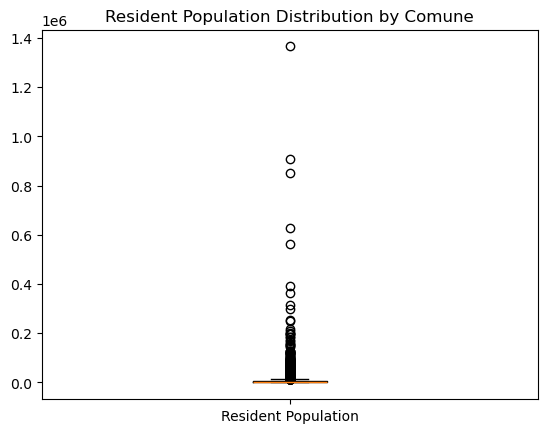

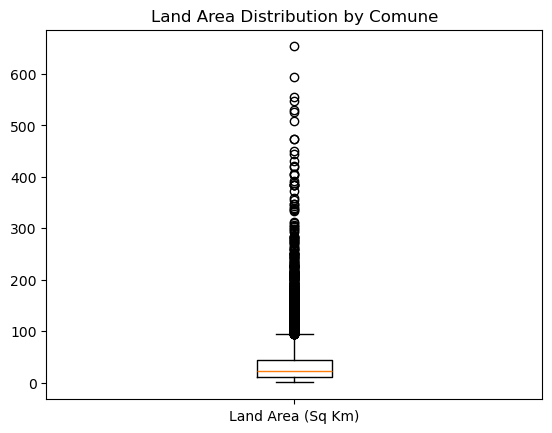

In [ ]:
print(df_situas_clean["Popolazione residente"].describe())

print(df_situas_clean["Superficie (Kmq)"].describe())

plt.boxplot(df_situas_clean["Popolazione residente"], tick_labels=["Resident Population"])
plt.title("Resident Population Distribution by Comune")
plt.show()

plt.boxplot(df_situas_clean["Superficie (Kmq)"], tick_labels=["Land Area (Sq Km)"])
plt.title("Land Area Distribution by Comune")
plt.show()